# В данном ноутбуке проходит вторая часть обучения МЕТА модели, а именно непосредственно ее обучение и поиск оптимальных порогов отсечения

# Создание и обучение Мета модели

# Загрузка данных

In [1]:
import numpy as np

# Загружаем логиты DenseNet-121
logits_data = np.load('densenet121_logits.npz')

# Записываем в переменные
train_logits_dn121 = logits_data['train_logits']
train_indices_dn121 = logits_data['train_indices']
val_logits_dn121 = logits_data['val_logits']
val_indices_dn121 = logits_data['val_indices']

print(" Логиты загружены в переменные")
print(f"   train_logits_dn121: {train_logits_dn121.shape}")
print(f"   val_logits_dn121: {val_logits_dn121.shape}")

✅ Логиты загружены в переменные
   train_logits_dn121: (78481, 15)
   val_logits_dn121: (16821, 15)


In [2]:
import numpy as np

# Загружаем логиты EfficientNet
effnet_data = np.load('efficientnet_logits.npz')

# Записываем в переменные
train_logits_effnet = effnet_data['train_logits']
train_indices_effnet = effnet_data['train_indices']
train_labels_effnet = effnet_data['train_labels']

val_logits_effnet = effnet_data['val_logits']
val_indices_effnet = effnet_data['val_indices']
val_labels_effnet = effnet_data['val_labels']

print(" Логиты EfficientNet загружены")
print(f"Train: {train_logits_effnet.shape}")
print(f"Val: {val_logits_effnet.shape}")

✅ Логиты EfficientNet загружены
Train: (78481, 15)
Val: (16821, 15)


In [3]:
import numpy as np

# Загружаем логиты Swin-Tiny
swin_data = np.load('swin_logits.npz')

# Записываем в переменные
train_logits_swin = swin_data['train_logits']
train_indices_swin = swin_data['train_indices']
train_labels_swin = swin_data['train_labels']

val_logits_swin = swin_data['val_logits']
val_indices_swin = swin_data['val_indices']
val_labels_swin = swin_data['val_labels']

print(" Логиты Swin-Tiny загружены")
print(f"Train: {train_logits_swin.shape}")
print(f"Val: {val_logits_swin.shape}")

 Логиты Swin-Tiny загружены
Train: (78481, 15)
Val: (16821, 15)


# обьединяем логиты для обучения

In [20]:
fuul_logits_train = np.concatenate((train_logits_dn121 , train_logits_effnet), axis = 1)

In [21]:
fuul_logits_train.shape

(78481, 30)

In [22]:
fuul_logits_train = np.concatenate((fuul_logits_train,train_logits_swin ), axis = 1)

In [23]:
fuul_logits_train.shape

(78481, 45)

In [42]:
full_logits_train = fuul_logits_train

# обьединяем логиты для валидации

In [28]:
full_logits_vald = np.concatenate((val_logits_dn121, val_logits_effnet), axis = 1)

In [29]:
full_logits_vald.shape

(16821, 30)

In [30]:
full_logits_vald = np.concatenate((full_logits_vald, val_logits_swin ), axis = 1)

In [31]:
full_logits_vald.shape

(16821, 45)

# проверим истинные метки классов

In [34]:
train_labels_effnet[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
      dtype=float32)

In [36]:
train_labels_swin[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
      dtype=float32)

In [37]:
val_labels_effnet[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [38]:
val_labels_swin[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

# истинные метки классов корректны

# создание модели

In [43]:
import torch
import numpy as np

print(" Проверяем данные для мета-нейросети")
print(f"   full_logits_train shape: {full_logits_train.shape}")
print(f"   full_logits_vald shape: {full_logits_vald.shape}")
print(f"   train_labels_effnet shape: {train_labels_effnet.shape}")
print(f"   val_labels_effnet shape: {val_labels_effnet.shape}")

# Проверяем размерности
assert full_logits_train.shape[1] == 45, f"Ожидается 45 признаков в train, получено {full_logits_train.shape[1]}"
assert full_logits_vald.shape[1] == 45, f"Ожидается 45 признаков в val, получено {full_logits_vald.shape[1]}"
assert train_labels_effnet.shape[1] == 15, "Ожидается 15 классов в train"
assert val_labels_effnet.shape[1] == 15, "Ожидается 15 классов в val"
assert full_logits_train.shape[0] == train_labels_effnet.shape[0], "Не совпадает количество train образцов"
assert full_logits_vald.shape[0] == val_labels_effnet.shape[0], "Не совпадает количество val образцов"

print(" Все данные корректны")

📊 Проверяем данные для мета-нейросети
   full_logits_train shape: (78481, 45)
   full_logits_vald shape: (16821, 45)
   train_labels_effnet shape: (78481, 15)
   val_labels_effnet shape: (16821, 15)
✅ Все данные корректны


In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📱 Устройство: {device}")

# Преобразуем numpy массивы в torch тензоры
train_logits_tensor = torch.tensor(full_logits_train, dtype=torch.float32).to(device)
train_labels_tensor = torch.tensor(train_labels_effnet, dtype=torch.float32).to(device)

val_logits_tensor = torch.tensor(full_logits_vald, dtype=torch.float32).to(device)
val_labels_tensor = torch.tensor(val_labels_effnet, dtype=torch.float32).to(device)

print(" Данные преобразованы в torch тензоры")
print(f"   Train logits: {train_logits_tensor.shape}")
print(f"   Train labels: {train_labels_tensor.shape}")
print(f"   Val logits: {val_logits_tensor.shape}")
print(f"   Val labels: {val_labels_tensor.shape}")

📱 Устройство: cuda
✅ Данные преобразованы в torch тензоры
   Train logits: torch.Size([78481, 45])
   Train labels: torch.Size([78481, 15])
   Val logits: torch.Size([16821, 45])
   Val labels: torch.Size([16821, 15])


In [45]:
import torch.nn as nn

class MetaNeuralNetwork(nn.Module):
    def __init__(self, input_size=45, hidden_size=1024, output_size=15):
        super(MetaNeuralNetwork, self).__init__()
        
        # Слой 1: 45 → 1024
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.sigmoid1 = nn.Sigmoid()
        self.dropout1 = nn.Dropout(0.5)
        
        # Слой 2: 1024 → 1024
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.sigmoid2 = nn.Sigmoid()
        self.dropout2 = nn.Dropout(0.5)
        
        # Выходной слой: 1024 → 15
        self.layer3 = nn.Linear(hidden_size, output_size)
        self.output_sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.sigmoid1(x)
        x = self.dropout1(x)
        
        x = self.layer2(x)
        x = self.sigmoid2(x)
        x = self.dropout2(x)
        
        x = self.layer3(x)
        x = self.output_sigmoid(x)
        return x

print(" Архитектура нейросети определена")
print(f"   Структура: 45 → 1024 → 1024 → 15")

✅ Архитектура нейросети определена
   Структура: 45 → 1024 → 1024 → 15


In [46]:
# Создаем модель
meta_model = MetaNeuralNetwork(
    input_size=45,
    hidden_size=1024,
    output_size=15
).to(device)

# Функция потерь для multi-label классификации
criterion = nn.BCELoss()

# Оптимизатор Adam
import torch.optim as optim
optimizer = optim.Adam(
    meta_model.parameters(),
    lr=0.001
)

print(" Модель и компоненты обучения созданы")
print(f"   Модель: MetaNeuralNetwork на {device}")
print(f"   Loss: BCELoss (для multi-label)")
print(f"   Optimizer: Adam (lr=0.001)")
print(f"   Параметров: {sum(p.numel() for p in meta_model.parameters()):,}")

✅ Модель и компоненты обучения созданы
   Модель: MetaNeuralNetwork на cuda
   Loss: BCELoss (для multi-label)
   Optimizer: Adam (lr=0.001)
   Параметров: 1,112,079


In [47]:
# ЯЧЕЙКА 5: Функции обучения и валидации
def train_epoch_simple(model, logits, labels, criterion, optimizer, batch_size=64):
    """
    Обучение одной эпохи без DataLoader
    """
    model.train()
    num_samples = len(logits)
    total_loss = 0
    num_batches = 0
    
    # Перемешиваем индексы для каждой эпохи
    indices = torch.randperm(num_samples)
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        
        batch_indices = indices[start_idx:end_idx]
        batch_logits = logits[batch_indices]
        batch_labels = labels[batch_indices]
        
        optimizer.zero_grad()
        predictions = model(batch_logits)
        loss = criterion(predictions, batch_labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

def validate_simple(model, logits, labels, criterion, batch_size=64):
    """
    Валидация без DataLoader
    """
    model.eval()
    num_samples = len(logits)
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            
            batch_logits = logits[start_idx:end_idx]
            batch_labels = labels[start_idx:end_idx]
            
            predictions = model(batch_logits)
            loss = criterion(predictions, batch_labels)
            
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / num_batches

print(" Функции обучения и валидации созданы")

✅ Функции обучения и валидации созданы


In [48]:
# ЯЧЕЙКА 6: Цикл обучения
num_epochs = 50
batch_size = 64
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience = 10
patience_counter = 0

print(f" Начинаем обучение на {num_epochs} эпох")
print("=" * 50)

for epoch in range(num_epochs):
    # Обучение
    train_loss = train_epoch_simple(
        meta_model, train_logits_tensor, train_labels_tensor, 
        criterion, optimizer, batch_size
    )
    
    # Валидация
    val_loss = validate_simple(
        meta_model, val_logits_tensor, val_labels_tensor,
        criterion, batch_size
    )
    
    # Сохраняем историю
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    # Вывод прогресса
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Эпоха [{epoch+1:3d}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # Ранняя остановка
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        
        # Сохраняем лучшую модель
        torch.save({
            'epoch': epoch,
            'model_state_dict': meta_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'history': history
        }, 'best_meta_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n Ранняя остановка на эпохе {epoch+1}")
            print(f"   Лучший Val Loss: {best_val_loss:.4f}")
            break

print("=" * 50)
print(f" Обучение завершено!")
print(f"   Лучший Val Loss: {best_val_loss:.4f}")
print(f"   Финальный Train Loss: {train_loss:.4f}")
print(f"   Финальный Val Loss: {val_loss:.4f}")

🚀 Начинаем обучение на 50 эпох
Эпоха [  1/50] | Train Loss: 0.1878 | Val Loss: 0.1739
Эпоха [  5/50] | Train Loss: 0.1736 | Val Loss: 0.1704
Эпоха [ 10/50] | Train Loss: 0.1721 | Val Loss: 0.1696
Эпоха [ 15/50] | Train Loss: 0.1714 | Val Loss: 0.1687
Эпоха [ 20/50] | Train Loss: 0.1708 | Val Loss: 0.1681
Эпоха [ 25/50] | Train Loss: 0.1702 | Val Loss: 0.1679
Эпоха [ 30/50] | Train Loss: 0.1698 | Val Loss: 0.1683
Эпоха [ 35/50] | Train Loss: 0.1698 | Val Loss: 0.1678
Эпоха [ 40/50] | Train Loss: 0.1693 | Val Loss: 0.1679
Эпоха [ 45/50] | Train Loss: 0.1692 | Val Loss: 0.1676
Эпоха [ 50/50] | Train Loss: 0.1689 | Val Loss: 0.1678
✅ Обучение завершено!
   Лучший Val Loss: 0.1674
   Финальный Train Loss: 0.1689
   Финальный Val Loss: 0.1678


In [49]:
# ЯЧЕЙКА 1: Получение предсказаний на валидационной выборке
print(" Получение предсказаний на валидационной выборке...")

meta_model.eval()  # Важно: выключаем Dropout для предсказаний

all_predictions = []
all_probabilities = []

with torch.no_grad():
    # Прогоняем всю валидационную выборку батчами
    batch_size = 64
    num_samples = len(val_logits_tensor)
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        
        batch_logits = val_logits_tensor[start_idx:end_idx]
        batch_predictions = meta_model(batch_logits)
        
        # Вероятности
        all_probabilities.append(batch_predictions.cpu())
        
        # Бинарные предсказания (порог 0.5)
        binary_preds = (batch_predictions > 0.5).float()
        all_predictions.append(binary_preds.cpu())

# Объединяем все батчи
all_probabilities = torch.cat(all_probabilities, dim=0).numpy()
all_predictions = torch.cat(all_predictions, dim=0).numpy()
all_true_labels = val_labels_tensor.cpu().numpy()

print(f" Предсказания получены:")
print(f"   Вероятности: {all_probabilities.shape}")
print(f"   Бинарные предсказания: {all_predictions.shape}")
print(f"   Истинные метки: {all_true_labels.shape}")

🧪 Получение предсказаний на валидационной выборке...
✅ Предсказания получены:
   Вероятности: (16821, 15)
   Бинарные предсказания: (16821, 15)
   Истинные метки: (16821, 15)


In [53]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

diseases_list = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 
                 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration',
                 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening',
                 'Pneumonia', 'Pneumothorax']

print("\n МЕТРИКИ КАЧЕСТВА ПО КЛАССАМ")
print("=" * 60)

for i, disease in enumerate(diseases_list):
    # Проверяем, есть ли этот класс в валидационной выборке
    if np.sum(all_true_labels[:, i]) > 0:
        # AUC-ROC
        auc = roc_auc_score(all_true_labels[:, i], all_probabilities[:, i])
        
        # Accuracy
        accuracy = accuracy_score(all_true_labels[:, i], all_predictions[:, i])
        
        # Precision, Recall, F1
        precision = precision_score(all_true_labels[:, i], all_predictions[:, i], zero_division=0)
        recall = recall_score(all_true_labels[:, i], all_predictions[:, i], zero_division=0)
        f1 = f1_score(all_true_labels[:, i], all_predictions[:, i], zero_division=0)
        
        # TP, FP, TN, FN
        tp = np.sum((all_predictions[:, i] == 1) & (all_true_labels[:, i] == 1))
        fp = np.sum((all_predictions[:, i] == 1) & (all_true_labels[:, i] == 0))
        tn = np.sum((all_predictions[:, i] == 0) & (all_true_labels[:, i] == 0))
        fn = np.sum((all_predictions[:, i] == 0) & (all_true_labels[:, i] == 1))
        
        print(f"\n{disease}:")
        print(f"  AUC:       {auc:.3f}")
        print(f"  Accuracy:  {accuracy:.3f}")
        print(f"  Precision: {precision:.3f}")
        print(f"  Recall:    {recall:.3f}")
        print(f"  F1-score:  {f1:.3f}")
        print(f"  TP: {tp:3d}, FP: {fp:3d}, TN: {tn:4d}, FN: {fn:3d}")

# ЯЧЕЙКА 3: Средние метрики по всем классам
print("\n" + "=" * 60)
print(" СРЕДНИЕ МЕТРИКИ ПО ВСЕМ КЛАССАМ")
print("=" * 60)

# Micro averaging (учитывает все предсказания вместе)
micro_auc = roc_auc_score(all_true_labels, all_probabilities, average='micro')
micro_accuracy = accuracy_score(all_true_labels.flatten(), all_predictions.flatten())
micro_precision = precision_score(all_true_labels, all_predictions, average='micro', zero_division=0)
micro_recall = recall_score(all_true_labels, all_predictions, average='micro', zero_division=0)
micro_f1 = f1_score(all_true_labels, all_predictions, average='micro', zero_division=0)

print(f"\n MICRO AVERAGING (учитывает все предсказания):")
print(f"  AUC:       {micro_auc:.3f}")
print(f"  Accuracy:  {micro_accuracy:.3f}")
print(f"  Precision: {micro_precision:.3f}")
print(f"  Recall:    {micro_recall:.3f}")
print(f"  F1-score:  {micro_f1:.3f}")

# Macro averaging (среднее по классам)
macro_auc = roc_auc_score(all_true_labels, all_probabilities, average='macro')
macro_accuracy = np.mean([accuracy_score(all_true_labels[:, i], all_predictions[:, i]) 
                          for i in range(len(diseases_list))])
macro_precision = precision_score(all_true_labels, all_predictions, average='macro', zero_division=0)
macro_recall = recall_score(all_true_labels, all_predictions, average='macro', zero_division=0)
macro_f1 = f1_score(all_true_labels, all_predictions, average='macro', zero_division=0)

print(f"\n MACRO AVERAGING (среднее по классам):")
print(f"  AUC:       {macro_auc:.3f}")
print(f"  Accuracy:  {macro_accuracy:.3f}")
print(f"  Precision: {macro_precision:.3f}")
print(f"  Recall:    {macro_recall:.3f}")
print(f"  F1-score:  {macro_f1:.3f}")

# Weighted averaging (с учетом количества образцов в каждом классе)
weighted_auc = roc_auc_score(all_true_labels, all_probabilities, average='weighted')
weighted_precision = precision_score(all_true_labels, all_predictions, average='weighted', zero_division=0)
weighted_recall = recall_score(all_true_labels, all_predictions, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_true_labels, all_predictions, average='weighted', zero_division=0)

print(f"\n WEIGHTED AVERAGING (с учетом дисбаланса классов):")
print(f"  AUC:       {weighted_auc:.3f}")
print(f"  Precision: {weighted_precision:.3f}")
print(f"  Recall:    {weighted_recall:.3f}")
print(f"  F1-score:  {weighted_f1:.3f}")


📊 МЕТРИКИ КАЧЕСТВА ПО КЛАССАМ

Atelectasis:
  AUC:       0.840
  Accuracy:  0.902
  Precision: 0.637
  Recall:    0.092
  F1-score:  0.161
  TP: 158, FP:  90, TN: 15020, FN: 1553

Cardiomegaly:
  AUC:       0.902
  Accuracy:  0.974
  Precision: 0.532
  Recall:    0.092
  F1-score:  0.157
  TP:  41, FP:  36, TN: 16341, FN: 403

Consolidation:
  AUC:       0.804
  Accuracy:  0.956
  Precision: 0.000
  Recall:    0.000
  F1-score:  0.000
  TP:   0, FP:   0, TN: 16081, FN: 740

Edema:
  AUC:       0.907
  Accuracy:  0.980
  Precision: 0.000
  Recall:    0.000
  F1-score:  0.000
  TP:   0, FP:   0, TN: 16484, FN: 337

Effusion:
  AUC:       0.896
  Accuracy:  0.899
  Precision: 0.680
  Recall:    0.306
  F1-score:  0.422
  TP: 620, FP: 292, TN: 14501, FN: 1408

Emphysema:
  AUC:       0.957
  Accuracy:  0.981
  Precision: 0.582
  Recall:    0.346
  F1-score:  0.434
  TP: 124, FP:  89, TN: 16374, FN: 234

Fibrosis:
  AUC:       0.847
  Accuracy:  0.985
  Precision: 0.000
  Recall:    0.000


используем сигмоиду

# Поиск порога отсечения

In [54]:
# ЯЧЕЙКА 1: Подготовка данных и базовые функции
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

print(" ПОДБОР ПОРОГОВ ДЛЯ КАЖДОГО КЛАССА")
print("=" * 60)

# Базовые функции для подбора порогов
def find_threshold_by_f1(probabilities, true_labels):
    """Находит порог, максимизирующий F1-score"""
    thresholds = np.linspace(0.01, 0.99, 100)
    best_f1 = 0
    best_threshold = 0.5
    
    for thresh in thresholds:
        preds = (probabilities > thresh).astype(int)
        f1 = f1_score(true_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    
    return best_threshold, best_f1

def find_threshold_by_youden(probabilities, true_labels):
    """Находит порог по критерию Юдена (J = sens + spec - 1)"""
    fpr, tpr, thresholds = roc_curve(true_labels, probabilities)
    youden_idx = np.argmax(tpr - fpr)
    return thresholds[youden_idx], tpr[youden_idx] - fpr[youden_idx]

def find_threshold_for_recall(probabilities, true_labels, target_recall=0.8):
    """Находит порог для достижения целевого recall"""
    thresholds = np.linspace(0.01, 0.99, 200)
    
    for thresh in thresholds[::-1]:  # Идем от высоких к низким
        preds = (probabilities > thresh).astype(int)
        rec = recall_score(true_labels, preds, zero_division=0)
        if rec >= target_recall:
            prec = precision_score(true_labels, preds, zero_division=0)
            f1 = f1_score(true_labels, preds, zero_division=0)
            return thresh, rec, prec, f1
    
    return 0.01, recall_score(true_labels, (probabilities > 0.01).astype(int), zero_division=0), 0, 0

🎯 ПОДБОР ПОРОГОВ ДЛЯ КАЖДОГО КЛАССА


In [55]:
# ЯЧЕЙКА 2: Подбор порогов разными методами
print("\n ПОДБОР ПОРОГОВ РАЗНЫМИ МЕТОДАМИ")
print("=" * 60)

thresholds_f1 = {}
thresholds_youden = {}
thresholds_recall80 = {}
thresholds_recall50 = {}

for i, disease in enumerate(diseases_list):
    if np.sum(all_true_labels[:, i]) > 0:
        probs = all_probabilities[:, i]
        labels = all_true_labels[:, i]
        
        # Метод 1: Оптимизация по F1
        thresh_f1, f1_val = find_threshold_by_f1(probs, labels)
        thresholds_f1[disease] = thresh_f1
        
        # Метод 2: Критерий Юдена
        thresh_y, youden_val = find_threshold_by_youden(probs, labels)
        thresholds_youden[disease] = thresh_y
        
        # Метод 3: Recall 80%
        thresh_r80, rec80, prec80, f1_80 = find_threshold_for_recall(probs, labels, target_recall=0.8)
        thresholds_recall80[disease] = thresh_r80
        
        # Метод 4: Recall 50%
        thresh_r50, rec50, prec50, f1_50 = find_threshold_for_recall(probs, labels, target_recall=0.5)
        thresholds_recall50[disease] = thresh_r50
        
        # Вывод
        print(f"\n{disease:20s}:")
        print(f"  F1-opt:    порог={thresh_f1:.3f}, F1={f1_val:.3f}")
        print(f"  Youden:    порог={thresh_y:.3f}, J={youden_val:.3f}")
        print(f"  Recall80%: порог={thresh_r80:.3f}, rec={rec80:.3f}, prec={prec80:.3f}, F1={f1_80:.3f}")
        print(f"  Recall50%: порог={thresh_r50:.3f}, rec={rec50:.3f}, prec={prec50:.3f}, F1={f1_50:.3f}")


🔍 ПОДБОР ПОРОГОВ РАЗНЫМИ МЕТОДАМИ

Atelectasis         :
  F1-opt:    порог=0.218, F1=0.428
  Youden:    порог=0.109, J=0.536
  Recall80%: порог=0.113, rec=0.801, prec=0.252, F1=0.384
  Recall50%: порог=0.232, rec=0.508, prec=0.362, F1=0.423

Cardiomegaly        :
  F1-opt:    порог=0.228, F1=0.385
  Youden:    порог=0.049, J=0.652
  Recall80%: порог=0.049, rec=0.818, prec=0.115, F1=0.202
  Recall50%: порог=0.163, rec=0.502, prec=0.279, F1=0.359

Consolidation       :
  F1-opt:    порог=0.129, F1=0.243
  Youden:    порог=0.046, J=0.476
  Recall80%: порог=0.040, rec=0.811, prec=0.099, F1=0.176
  Recall50%: порог=0.104, rec=0.515, prec=0.144, F1=0.225

Edema               :
  F1-opt:    порог=0.129, F1=0.251
  Youden:    порог=0.023, J=0.672
  Recall80%: порог=0.035, rec=0.804, prec=0.092, F1=0.166
  Recall50%: порог=0.108, rec=0.501, prec=0.162, F1=0.244

Effusion            :
  F1-opt:    порог=0.307, F1=0.577
  Youden:    порог=0.091, J=0.630
  Recall80%: порог=0.148, rec=0.803, prec


📈 ВИЗУАЛИЗАЦИЯ PRECISION-RECALL КРИВЫХ


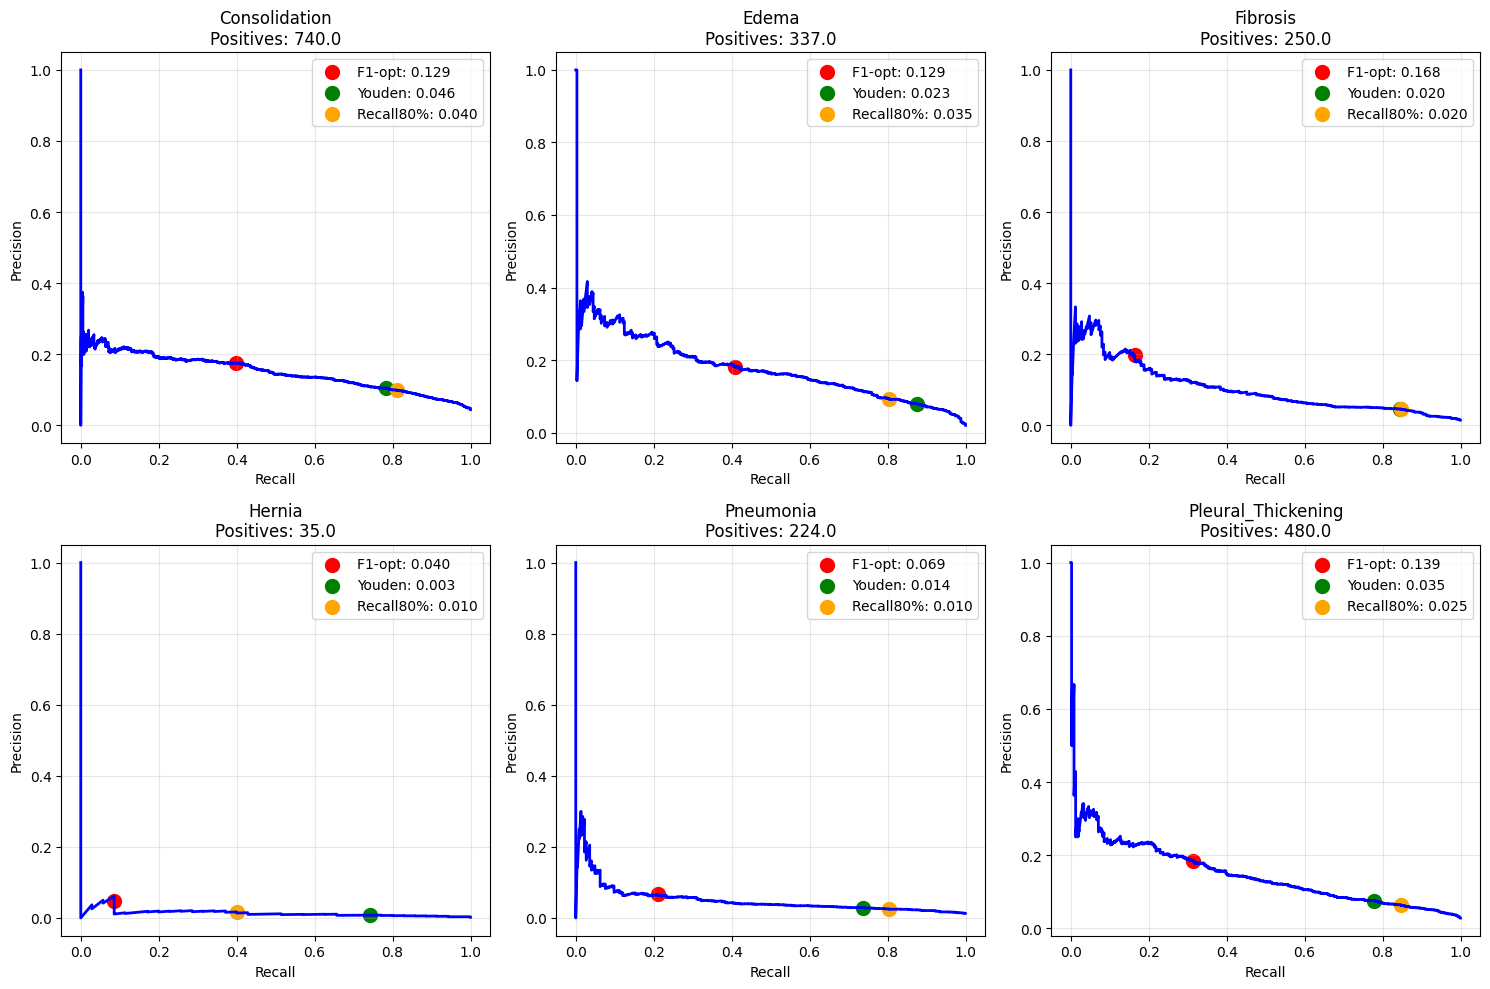

In [56]:
# ЯЧЕЙКА 3: Визуализация Precision-Recall кривых
print("\n ВИЗУАЛИЗАЦИЯ PRECISION-RECALL КРИВЫХ")
print("=" * 60)

# Создаем графики для 6 проблемных классов
problem_classes = ['Consolidation', 'Edema', 'Fibrosis', 'Hernia', 'Pneumonia', 'Pleural_Thickening']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, disease in enumerate(problem_classes):
    if disease in diseases_list:
        i = diseases_list.index(disease)
        probs = all_probabilities[:, i]
        labels = all_true_labels[:, i]
        
        if np.sum(labels) > 0:
            precision, recall, thresholds_pr = precision_recall_curve(labels, probs)
            
            axes[idx].plot(recall, precision, 'b-', linewidth=2)
            axes[idx].set_xlabel('Recall')
            axes[idx].set_ylabel('Precision')
            axes[idx].set_title(f'{disease}\nPositives: {np.sum(labels)}')
            axes[idx].grid(True, alpha=0.3)
            
            # Отмечаем разные пороги
            for method, thresh, color in [
                ('F1-opt', thresholds_f1.get(disease, 0.5), 'red'),
                ('Youden', thresholds_youden.get(disease, 0.5), 'green'),
                ('Recall80%', thresholds_recall80.get(disease, 0.5), 'orange')
            ]:
                if thresh < 1.0:  # Избегаем крайних значений
                    preds = (probs > thresh).astype(int)
                    p = precision_score(labels, preds, zero_division=0)
                    r = recall_score(labels, preds, zero_division=0)
                    axes[idx].scatter(r, p, color=color, s=100, label=f'{method}: {thresh:.3f}')
            
            axes[idx].legend(loc='best')

plt.tight_layout()
plt.show()

In [57]:
# ЯЧЕЙКА 4: Анализ распределения вероятностей для проблемных классов
print("\n РАСПРЕДЕЛЕНИЕ ВЕРОЯТНОСТЕЙ ДЛЯ ПРОБЛЕМНЫХ КЛАССОВ")
print("=" * 60)

for disease in ['Consolidation', 'Edema', 'Fibrosis', 'Hernia', 'Pneumonia']:
    if disease in diseases_list:
        i = diseases_list.index(disease)
        probs = all_probabilities[:, i]
        labels = all_true_labels[:, i]
        
        if np.sum(labels) > 0:
            print(f"\n{disease}:")
            print(f"  Всего образцов: {len(probs)}")
            print(f"  Положительных: {np.sum(labels)} ({np.sum(labels)/len(probs)*100:.1f}%)")
            
            # Для положительных случаев
            pos_probs = probs[labels == 1]
            print(f"  Вероятности для положительных:")
            print(f"    Min: {pos_probs.min():.3f}")
            print(f"    Max: {pos_probs.max():.3f}")
            print(f"    Mean: {pos_probs.mean():.3f}")
            print(f"    Median: {np.median(pos_probs):.3f}")
            print(f"    90% квантиль: {np.quantile(pos_probs, 0.9):.3f}")
            
            # Сколько выше порога 0.5
            above_05 = (pos_probs > 0.5).sum()
            print(f"    Выше 0.5: {above_05}/{len(pos_probs)} ({above_05/len(pos_probs)*100:.1f}%)")
            
            # Предлагаемый порог на основе квантиля
            suggested_thresh = np.quantile(pos_probs, 0.1)  # Нижний 10% квантиль
            print(f"  Предлагаемый порог (10% квантиль): {suggested_thresh:.3f}")


📊 РАСПРЕДЕЛЕНИЕ ВЕРОЯТНОСТЕЙ ДЛЯ ПРОБЛЕМНЫХ КЛАССОВ

Consolidation:
  Всего образцов: 16821
  Положительных: 740.0 (4.4%)
  Вероятности для положительных:
    Min: 0.003
    Max: 0.264
    Mean: 0.106
    Median: 0.105
    90% квантиль: 0.184
    Выше 0.5: 0/740 (0.0%)
  Предлагаемый порог (10% квантиль): 0.020

Edema:
  Всего образцов: 16821
  Положительных: 337.0 (2.0%)
  Вероятности для положительных:
    Min: 0.000
    Max: 0.476
    Mean: 0.116
    Median: 0.110
    90% квантиль: 0.218
    Выше 0.5: 0/337 (0.0%)
  Предлагаемый порог (10% квантиль): 0.018

Fibrosis:
  Всего образцов: 16821
  Положительных: 250.0 (1.5%)
  Вероятности для положительных:
    Min: 0.001
    Max: 0.460
    Mean: 0.087
    Median: 0.054
    90% квантиль: 0.204
    Выше 0.5: 0/250 (0.0%)
  Предлагаемый порог (10% квантиль): 0.013

Hernia:
  Всего образцов: 16821
  Положительных: 35.0 (0.2%)
  Вероятности для положительных:
    Min: 0.000
    Max: 0.053
    Mean: 0.011
    Median: 0.007
    90% квантиль: 

In [58]:
# ЯЧЕЙКА 5: Практические рекомендации по порогам
print("\n ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО ПОРОГАМ")
print("=" * 60)

# Агрегируем рекомендации из разных методов
final_thresholds = {}

for disease in diseases_list:
    if disease in thresholds_f1:
        # Для редких классов используем Recall-based подход
        class_freq = np.sum(all_true_labels[:, diseases_list.index(disease)]) / len(all_true_labels)
        
        if class_freq < 0.01:  # Очень редкие (<1%)
            # Берём минимум из Recall50% и 10% квантиля
            i = diseases_list.index(disease)
            pos_probs = all_probabilities[all_true_labels[:, i] == 1, i]
            if len(pos_probs) > 0:
                quantile_10 = np.quantile(pos_probs, 0.1)
                final_thresh = min(thresholds_recall50.get(disease, 0.5), quantile_10)
                final_thresh = max(0.05, min(0.3, final_thresh))  # Ограничиваем 0.05-0.3
            else:
                final_thresh = 0.1
        
        elif class_freq < 0.05:  # Редкие (1-5%)
            # Среднее между F1-opt и Recall50%
            thresh_f1 = thresholds_f1.get(disease, 0.5)
            thresh_r50 = thresholds_recall50.get(disease, 0.5)
            final_thresh = (thresh_f1 + thresh_r50) / 2
            final_thresh = max(0.1, min(0.4, final_thresh))
        
        else:  # Частые (>5%)
            # Используем F1-opt, но не ниже 0.3
            final_thresh = max(0.3, thresholds_f1.get(disease, 0.5))
        
        final_thresholds[disease] = final_thresh

# Выводим финальные пороги
print("\nРекомендованные пороги:")
print("-" * 50)
for disease, thresh in final_thresholds.items():
    i = diseases_list.index(disease)
    class_freq = np.sum(all_true_labels[:, i]) / len(all_true_labels)
    print(f"{disease:20s}: порог={thresh:.3f} (частота: {class_freq:.3%})")


🎯 ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО ПОРОГАМ

Рекомендованные пороги:
--------------------------------------------------
Atelectasis         : порог=0.300 (частота: 10.172%)
Cardiomegaly        : порог=0.195 (частота: 2.640%)
Consolidation       : порог=0.116 (частота: 4.399%)
Edema               : порог=0.119 (частота: 2.003%)
Effusion            : порог=0.307 (частота: 12.056%)
Emphysema           : порог=0.326 (частота: 2.128%)
Fibrosis            : порог=0.111 (частота: 1.486%)
Hernia              : порог=0.050 (частота: 0.208%)
Infiltration        : порог=0.300 (частота: 17.823%)
Mass                : порог=0.227 (частота: 4.786%)
No Finding          : порог=0.376 (частота: 53.837%)
Nodule              : порог=0.300 (частота: 5.695%)
Pleural_Thickening  : порог=0.111 (частота: 2.854%)
Pneumonia           : порог=0.100 (частота: 1.332%)
Pneumothorax        : порог=0.289 (частота: 4.613%)


In [59]:
# ЯЧЕЙКА 6: Тестирование рекомендованных порогов
print("\n ТЕСТИРОВАНИЕ РЕКОМЕНДОВАННЫХ ПОРОГОВ")
print("=" * 60)

# Функция для оценки с кастомными порогами
def evaluate_with_thresholds(probabilities, true_labels, thresholds_dict):
    predictions = np.zeros_like(probabilities)
    
    for i, disease in enumerate(diseases_list):
        threshold = thresholds_dict.get(disease, 0.5)
        predictions[:, i] = (probabilities[:, i] > threshold).astype(float)
    
    return predictions

# Применяем рекомендованные пороги
custom_predictions = evaluate_with_thresholds(all_probabilities, all_true_labels, final_thresholds)

# Сравниваем метрики
print("\nСРАВНЕНИЕ МЕТРИК:")
print("-" * 50)
print(f"{'Класс':20s} {'Порог':10s} {'Recall (старый)':15s} {'Recall (новый)':15s} {'F1 (старый)':12s} {'F1 (новый)':12s}")
print("-" * 80)

for disease in diseases_list:
    i = diseases_list.index(disease)
    if np.sum(all_true_labels[:, i]) > 0:
        # Старые метрики (порог 0.5)
        old_preds = (all_probabilities[:, i] > 0.5).astype(int)
        old_recall = recall_score(all_true_labels[:, i], old_preds, zero_division=0)
        old_f1 = f1_score(all_true_labels[:, i], old_preds, zero_division=0)
        
        # Новые метрики
        new_preds = custom_predictions[:, i].astype(int)
        new_recall = recall_score(all_true_labels[:, i], new_preds, zero_division=0)
        new_f1 = f1_score(all_true_labels[:, i], new_preds, zero_division=0)
        
        print(f"{disease:20s} {final_thresholds.get(disease, 0.5):10.3f} "
              f"{old_recall:15.3f} {new_recall:15.3f} "
              f"{old_f1:12.3f} {new_f1:12.3f}")


🧪 ТЕСТИРОВАНИЕ РЕКОМЕНДОВАННЫХ ПОРОГОВ

СРАВНЕНИЕ МЕТРИК:
--------------------------------------------------
Класс                Порог      Recall (старый) Recall (новый)  F1 (старый)  F1 (новый)  
--------------------------------------------------------------------------------
Atelectasis               0.300           0.092           0.371        0.161        0.400
Cardiomegaly              0.195           0.092           0.437        0.157        0.370
Consolidation             0.116           0.000           0.454        0.000        0.233
Edema                     0.119           0.000           0.460        0.000        0.249
Effusion                  0.307           0.306           0.614        0.422        0.577
Emphysema                 0.326           0.346           0.561        0.434        0.511
Fibrosis                  0.111           0.000           0.240        0.000        0.174
Hernia                    0.050           0.000           0.029        0.000        0.031

In [60]:
# ЯЧЕЙКА 7: Итоговые пороги для использования
print("\n ИТОГОВЫЕ ПОРОГИ ДЛЯ ИСПОЛЬЗОВАНИЯ")
print("=" * 60)

# Округляем до разумных значений
final_thresholds_rounded = {}
for disease, thresh in final_thresholds.items():
    # Округляем до 0.05
    rounded = round(thresh / 0.05) * 0.05
    final_thresholds_rounded[disease] = max(0.05, min(0.95, rounded))

print("\nОкругленные пороги:")
print("-" * 50)
for disease, thresh in final_thresholds_rounded.items():
    print(f"    '{disease}': {thresh:.2f},")

# Сохраняем пороги в файл
import json
with open('optimal_thresholds.json', 'w') as f:
    json.dump(final_thresholds_rounded, f, indent=2)

print(f"\n Пороги сохранены в 'optimal_thresholds.json'")


🎯 ИТОГОВЫЕ ПОРОГИ ДЛЯ ИСПОЛЬЗОВАНИЯ

Округленные пороги:
--------------------------------------------------
    'Atelectasis': 0.30,
    'Cardiomegaly': 0.20,
    'Consolidation': 0.10,
    'Edema': 0.10,
    'Effusion': 0.30,
    'Emphysema': 0.35,
    'Fibrosis': 0.10,
    'Hernia': 0.05,
    'Infiltration': 0.30,
    'Mass': 0.25,
    'No Finding': 0.40,
    'Nodule': 0.30,
    'Pleural_Thickening': 0.10,
    'Pneumonia': 0.10,
    'Pneumothorax': 0.30,

💾 Пороги сохранены в 'optimal_thresholds.json'


In [61]:
# ЯЧЕЙКА 8: Функция для применения порогов в будущем
print("\n ФУНКЦИЯ ДЛЯ ПРИМЕНЕНИЯ ПОРОГОВ")
print("=" * 60)

def apply_optimal_thresholds(probabilities, thresholds_dict=None):
    """
    Применяет оптимальные пороги к вероятностям
    
    Args:
        probabilities: numpy array [N, 15] - вероятности от модели
        thresholds_dict: словарь {class_name: threshold}, если None - загружает из файла
    
    Returns:
        binary_predictions: numpy array [N, 15] - бинарные предсказания
    """
    if thresholds_dict is None:
        import json
        with open('optimal_thresholds.json', 'r') as f:
            thresholds_dict = json.load(f)
    
    predictions = np.zeros_like(probabilities)
    
    for i, disease in enumerate(diseases_list):
        threshold = thresholds_dict.get(disease, 0.5)
        predictions[:, i] = (probabilities[:, i] > threshold).astype(float)
    
    return predictions

# Пример использования
print("Пример использования функции:")
print("""
# Загружаем вероятности от модели
probabilities = model.predict(...)  # [N, 15]

# Применяем оптимальные пороги
predictions = apply_optimal_thresholds(probabilities)

# predictions теперь содержат бинарные предсказания
print(f"Размер предсказаний: {predictions.shape}")
""")


🔧 ФУНКЦИЯ ДЛЯ ПРИМЕНЕНИЯ ПОРОГОВ
Пример использования функции:

# Загружаем вероятности от модели
probabilities = model.predict(...)  # [N, 15]

# Применяем оптимальные пороги
predictions = apply_optimal_thresholds(probabilities)

# predictions теперь содержат бинарные предсказания
print(f"Размер предсказаний: {predictions.shape}")



# сохранение полной МЕТА модели

In [63]:
from datetime import datetime
import os
import torch
import json
import numpy as np

print(" Сохранение полной мета-модели с конфигурацией...")

# Собираем полный чекпоинт с метаданными
full_checkpoint = {
    # Архитектура и веса
    'model_state_dict': meta_model.state_dict(),
    'model_architecture': {
        'input_size': 45,
        'hidden_size': 1024,
        'output_size': 15,
        'dropout_rate': 0.5
    },
    
    # Оптимальные пороги
    'optimal_thresholds': final_thresholds_rounded,
    
    # Список заболеваний (важен порядок!)
    'diseases_list': diseases_list,
    
    # Индекс "No Finding" для логики обработки
    'no_finding_index': diseases_list.index('No Finding'),
    
    # История обучения
    'training_history': history,
    
    # Метрики на валидации
    'validation_metrics': {
        'best_val_loss': best_val_loss,
        'final_val_loss': history['val_loss'][-1] if history['val_loss'] else None
    },
    
    # Информация о базовых моделях
    'base_models_info': {
        'count': 3,
        'models': ['DenseNet-121', 'EfficientNetV2-S', 'Swin Transformer Tiny'],
        'input_features_per_model': 15
    },
    
    # Дата и версия
    'save_timestamp': str(datetime.now()),
    'version': '1.0'
}

# Сохраняем полную модель
torch.save(full_checkpoint, 'full_meta_model.pth')
print(" Полная мета-модель сохранена в 'full_meta_model.pth'")

# Дополнительно сохраняем легковесную версию (только веса + конфиг)
light_checkpoint = {
    'model_state_dict': meta_model.state_dict(),
    'optimal_thresholds': final_thresholds_rounded,
    'diseases_list': diseases_list,
    'model_config': {
        'input_size': 45,
        'hidden_size': 1024,
        'output_size': 15
    }
}
torch.save(light_checkpoint, 'meta_model_light.pth')
print(" Легковесная версия сохранена в 'meta_model_light.pth'")

# Сохраняем пороги отдельно в JSON (для удобства использования)
thresholds_for_use = {
    'thresholds': final_thresholds_rounded,
    'diseases_order': diseases_list,
    'notes': 'Оптимальные пороги классификации для каждого заболевания'
}

with open('classification_thresholds.json', 'w') as f:
    json.dump(thresholds_for_use, f, indent=2, ensure_ascii=False)

print(" Пороги классификации сохранены в 'classification_thresholds.json'")

# Проверка сохраненных файлов
print("\n Проверка сохраненных файлов:")
print(f"   • full_meta_model.pth - {os.path.getsize('full_meta_model.pth') / 1024 / 1024:.1f} MB")
print(f"   • meta_model_light.pth - {os.path.getsize('meta_model_light.pth') / 1024 / 1024:.1f} MB")
print(f"   • classification_thresholds.json - {os.path.getsize('classification_thresholds.json') / 1024:.1f} KB")

# Пример загрузки модели
print("\n Пример загрузки модели:")
print("""
# Загрузка модели
checkpoint = torch.load('meta_model_light.pth', map_location=device)

# Создание архитектуры
loaded_model = MetaNeuralNetwork(
    input_size=checkpoint['model_config']['input_size'],
    hidden_size=checkpoint['model_config']['hidden_size'],
    output_size=checkpoint['model_config']['output_size']
).to(device)

# Загрузка весов
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

# Использование порогов
thresholds = checkpoint['optimal_thresholds']
diseases_list = checkpoint['diseases_list']
""")

💾 Сохранение полной мета-модели с конфигурацией...
✅ Полная мета-модель сохранена в 'full_meta_model.pth'
✅ Легковесная версия сохранена в 'meta_model_light.pth'
✅ Пороги классификации сохранены в 'classification_thresholds.json'

📁 Проверка сохраненных файлов:
   • full_meta_model.pth - 4.2 MB
   • meta_model_light.pth - 4.2 MB
   • classification_thresholds.json - 0.8 KB

🔧 Пример загрузки модели:

# Загрузка модели
checkpoint = torch.load('meta_model_light.pth', map_location=device)

# Создание архитектуры
loaded_model = MetaNeuralNetwork(
    input_size=checkpoint['model_config']['input_size'],
    hidden_size=checkpoint['model_config']['hidden_size'],
    output_size=checkpoint['model_config']['output_size']
).to(device)

# Загрузка весов
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

# Использование порогов
thresholds = checkpoint['optimal_thresholds']
diseases_list = checkpoint['diseases_list']



# Создаем пайтон файл, для полной загрузки мета модели

In [64]:
%%writefile meta_model.py

import torch
import torch.nn as nn
import numpy as np
import json
import os
from typing import Dict, List, Tuple

class MetaNeuralNetwork(nn.Module):
    def __init__(self, input_size: int = 45, hidden_size: int = 1024, output_size: int = 15):
        super(MetaNeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.sigmoid1 = nn.Sigmoid()
        self.dropout1 = nn.Dropout(0.5)
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.sigmoid2 = nn.Sigmoid()
        self.dropout2 = nn.Dropout(0.5)
        self.layer3 = nn.Linear(hidden_size, output_size)
        self.output_sigmoid = nn.Sigmoid()
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layer1(x)
        x = self.sigmoid1(x)
        x = self.dropout1(x)
        x = self.layer2(x)
        x = self.sigmoid2(x)
        x = self.dropout2(x)
        x = self.layer3(x)
        x = self.output_sigmoid(x)
        return x

class MetaModelPredictor:
    def __init__(self, model_path: str = 'full_meta_model.pth', device: str = None):
        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        self.model, self.config = self._load_model(model_path)
        self.model.eval()
        self.thresholds = self.config['optimal_thresholds']
        self.diseases_list = self.config['diseases_list']
        self.no_finding_idx = self.diseases_list.index('No Finding')
    
    def _load_model(self, model_path: str) -> Tuple[nn.Module, Dict]:
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Файл модели не найден: {model_path}")
        
        checkpoint = torch.load(model_path, map_location=self.device, weights_only=False)
        
        if 'model_config' in checkpoint:
            config = checkpoint['model_config']
            model = MetaNeuralNetwork(
                input_size=config['input_size'],
                hidden_size=config['hidden_size'],
                output_size=config['output_size']
            )
        else:
            config = checkpoint['model_architecture']
            model = MetaNeuralNetwork(
                input_size=config['input_size'],
                hidden_size=config['hidden_size'],
                output_size=config['output_size']
            )
        
        model.load_state_dict(checkpoint['model_state_dict'])
        model = model.to(self.device)
        
        model_config = {
            'optimal_thresholds': checkpoint.get('optimal_thresholds', {}),
            'diseases_list': checkpoint.get('diseases_list', []),
            'model_architecture': config
        }
        
        return model, model_config
    
    def predict(self, logits_array: np.ndarray, apply_thresholds: bool = True) -> Dict:
        if logits_array.shape[1] != 45:
            raise ValueError(f"Ожидается 45 признаков, получено {logits_array.shape[1]}")
        
        logits_tensor = torch.tensor(logits_array, dtype=torch.float32).to(self.device)
        
        with torch.no_grad():
            probabilities = self.model(logits_tensor)
            probabilities_np = probabilities.cpu().numpy()
        
        if apply_thresholds:
            binary_predictions = self._apply_thresholds(probabilities_np)
            binary_predictions = self._apply_no_finding_logic(binary_predictions)
        else:
            binary_predictions = None
        
        return {
            'probabilities': probabilities_np,
            'binary_predictions': binary_predictions,
            'diseases': self.diseases_list
        }
    
    def _apply_thresholds(self, probabilities: np.ndarray) -> np.ndarray:
        binary = np.zeros_like(probabilities)
        for i, disease in enumerate(self.diseases_list):
            threshold = self.thresholds.get(disease, 0.5)
            binary[:, i] = (probabilities[:, i] > threshold).astype(float)
        return binary
    
    def _apply_no_finding_logic(self, predictions: np.ndarray) -> np.ndarray:
        result = predictions.copy()
        no_finding_mask = result[:, self.no_finding_idx] == 1
        result[no_finding_mask, :] = 0
        result[no_finding_mask, self.no_finding_idx] = 1
        return result
    
    def predict_single(self, logits: np.ndarray) -> Dict:
        logits_batch = logits.reshape(1, -1)
        results = self.predict(logits_batch, apply_thresholds=True)
        
        return {
            'probabilities': results['probabilities'][0],
            'binary_predictions': results['binary_predictions'][0],
            'diseases': self.diseases_list,
            'predicted_diseases': [
                self.diseases_list[i] 
                for i in range(len(self.diseases_list)) 
                if results['binary_predictions'][0, i] == 1
            ]
        }
    
    def get_thresholds(self) -> Dict:
        return self.thresholds.copy()
    
    def get_diseases_list(self) -> List[str]:
        return self.diseases_list.copy()

def load_meta_model(model_path: str = 'full_meta_model.pth', device: str = None):
    """Быстрая загрузка мета-модели"""
    return MetaModelPredictor(model_path, device)

Writing meta_model.py
